In [1]:
#import libraries
import pandas as pd
import numpy as np

In [2]:
train_features = pd.read_csv('/content/training_set_features.csv')
train_labels = pd.read_csv('/content/training_set_labels.csv')
test_data = pd.read_csv('/content/test_set_features.csv')
test_data1 = pd.read_csv('/content/test_set_features.csv')

In [3]:
trainData = pd.merge(train_features, train_labels, on='respondent_id')

# Data Preprocessing
**Updating Employement Status based on "age_group"**

In [4]:
columns = ['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine']

In [5]:
def update_employment_status(df):
  for index, row in df.iterrows():
    if pd.isnull(row['employment_status']):
      if row['age_group'] == '65+ Years':
        df.loc[index, 'employment_status'] = 'Not in Labor Force'
      else:
        df.loc[index, 'employment_status'] = 'Unemployed'
  return df

In [6]:
trainData = update_employment_status(trainData)

In [7]:
binary_columns = [
    'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
    'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'child_under_6_months', 'health_worker'
]
for col in binary_columns:
    trainData[col] = trainData[col].fillna(trainData[col].mode()[0])

In [8]:
scaled_columns = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc'
]
for col in scaled_columns:
    trainData[col] = trainData[col].fillna(trainData[col].mode()[0])

**Updating Education Status based on "age_group" by MODE value**


In [9]:
def update_education(df):
  age_groups = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
  # age_groups = '18 - 34 Years'
  for age_group in age_groups:
      mode_education = df.loc[df['age_group'] == age_group, 'education'].mode()

      if not mode_education.empty:
          mode_education = mode_education[0]
          df.loc[(df['age_group'] == age_group) & (df['education'].isnull()), 'education'] = mode_education
  return df

trainData = update_education(trainData)

In [10]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

kNN_features_missing = ['income_poverty', 'health_insurance', 'rent_or_own', 'marital_status']
kNN_reference_features = ['employment_status', 'race', 'sex', 'age_group', 'education']
kNN_features = list(set(kNN_features_missing + kNN_reference_features))

label_encoders = {}
for col in kNN_features:
    le = LabelEncoder()
    trainData[col] = le.fit_transform(trainData[col].astype(str))
    label_encoders[col] = le

knn_imputer = KNNImputer(n_neighbors=3)
trainData[kNN_features] = knn_imputer.fit_transform(trainData[kNN_features])

# Decode back to categories
for col in kNN_features:
    trainData[col] = label_encoders[col].inverse_transform(trainData[col].round().astype(int))


In [11]:
trainData.isnull().sum()

,0
respondent_id,0
h1n1_concern,0
h1n1_knowledge,0
behavioral_antiviral_meds,0
behavioral_avoidance,0
behavioral_face_mask,0
behavioral_wash_hands,0
behavioral_large_gatherings,0
behavioral_outside_home,0
behavioral_touch_face,0


In [12]:
cat_features = ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status',
                'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa']
label_encoders_cb = {}

for col in cat_features:
    le = LabelEncoder()
    trainData[col] = le.fit_transform(trainData[col].astype(str))
    label_encoders_cb[col] = le

# ---------------------- 7️⃣ Feature Selection ----------------------
top_features = [
    'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_seas_sick_from_vacc',
    'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'h1n1_concern',
    'opinion_seas_risk', 'health_worker', 'h1n1_knowledge', 'household_children',
    'household_adults', 'doctor_recc_seasonal', 'doctor_recc_h1n1',
    'behavioral_large_gatherings', 'census_msa',
    'age_group', 'sex', 'education', 'marital_status'
]

target_cols = ['h1n1_vaccine', 'seasonal_vaccine']
final_features = list(set(top_features + target_cols))
training_data_selected = trainData[final_features]

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ✅ Drop respondent_id from features
X = training_data_selected.drop(columns=['h1n1_vaccine', 'seasonal_vaccine'])
test_data_encoded = training_data_selected.drop(columns=['respondent_id'], errors='ignore')

# ✅ Define target variables
y_h1n1 = training_data_selected['h1n1_vaccine']
y_seasonal = training_data_selected['seasonal_vaccine']

# ✅ Split Data into Training & Validation Sets (80-20 split)
X_train_h1n1, X_valid_h1n1, y_train_h1n1, y_valid_h1n1 = train_test_split(X, y_h1n1, test_size=0.2, random_state=42)
X_train_seasonal, X_valid_seasonal, y_train_seasonal, y_valid_seasonal = train_test_split(X, y_seasonal, test_size=0.2, random_state=42)


# ✅ Scale Data for NGBoost & HistGB (CatBoost does not need scaling)
imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()
X_h1n1_scaled = scaler.fit_transform(imputer.fit_transform(X_train_h1n1))
X_seasonal_scaled = scaler.fit_transform(imputer.fit_transform(X_train_seasonal))
X_h1n1 = imputer.fit_transform(X_valid_h1n1)
X_seasonal = imputer.fit_transform(X_valid_seasonal)

# same transforms for TEST SET
onehot_cols = ['age_group','education','race','sex','income_poverty','marital_status',
               'rent_or_own','employment_status','hhs_geo_region','census_msa']
test_enc = pd.get_dummies(test_data, columns=onehot_cols, drop_first=True)
for col in ["employment_industry","employment_occupation"]:
    le = LabelEncoder()
    le.fit(test_data[col].astype(str))
    test_enc[col] = le.transform(test_data[col].astype(str))

# align cols
missing_cols = set(training_data_selected.columns) - set(test_enc.columns)
missing_cols.discard("h1n1_vaccine"); missing_cols.discard("seasonal_vaccine")
for c in missing_cols: test_enc[c] = 0
test_enc = test_enc[training_data_selected.drop(columns=["h1n1_vaccine","seasonal_vaccine"]).columns]

test_scaled = scaler.transform(imputer.transform(test_enc))
test_unscaled = imputer.transform(test_enc)



In [28]:
# with CV

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from ngboost import NGBClassifier
from ngboost.learners import default_tree_learner
from ngboost.distns import Bernoulli
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score

# # Assume training_data_encoded and test_data_encoded are already preprocessed and available
# # Define features and targets
# X = training_data_encoded.drop(columns=['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine'])
# y_h1n1 = training_data_encoded['h1n1_vaccine']
# y_seasonal = training_data_encoded['seasonal_vaccine']
# test_data = test_data_encoded.drop(columns=['respondent_id'], errors='ignore')

# # Impute and scale
# imputer = SimpleImputer(strategy="mean")
# scaler = StandardScaler()

# X_h1n1_scaled = scaler.fit_transform(imputer.fit_transform(X))
# X_seasonal_scaled = scaler.fit_transform(imputer.fit_transform(X))
# X_h1n1 = imputer.fit_transform(X)
# X_seasonal = imputer.fit_transform(X)

# test_scaled = scaler.transform(imputer.transform(test_data))
# test_unscaled = imputer.transform(test_data)

# Stratified K-Fold
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

def cross_val_model(model_fn, X, y, X_test, model_name):
    X_np = X.values if isinstance(X, pd.DataFrame) else X
    y_np = y.values.ravel() if isinstance(y, (pd.Series, pd.DataFrame)) else y

    oof_preds  = np.zeros(len(y_np))
    test_preds = np.zeros(X_test.shape[0])
    aucs       = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y_np)):
        X_tr, X_val = X_np[train_idx], X_np[val_idx]
        y_tr, y_val = y_np[train_idx], y_np[val_idx]

        model = model_fn()
        model.fit(X_tr, y_tr)

        val_probs  = model.predict_proba(X_val)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]

        oof_preds[val_idx] = val_probs
        test_preds        += test_probs / N_FOLDS
        auc                = roc_auc_score(y_val, val_probs)
        aucs.append(auc)
        print(f"📊 Fold {fold+1} AUC ({model_name}): {auc:.5f}")

    print(f"✅ Mean AUC for {model_name}: {np.mean(aucs):.5f}")
    return test_preds, np.mean(aucs)


# Model wrappers
histgb_fn = lambda: HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=6, min_samples_leaf=20, random_state=42)
catboost_fn = lambda: CatBoostClassifier(iterations=500, learning_rate=0.05745075659543725, depth=6, loss_function='Logloss', verbose=0, random_strength=4,
    bagging_temperature=8,
    max_bin=5,
    grow_policy= "Lossguide",
    min_data_in_leaf=7,
    l2_leaf_reg=11.323094517862078,
    one_hot_max_size=10,
    auto_class_weights="Balanced", random_state=42)
ngboost_fn = lambda: NGBClassifier(Dist=Bernoulli, Base=default_tree_learner, n_estimators=500, learning_rate=0.05, minibatch_frac=0.8, random_state=42)
rf_h1n1_fn = lambda: RandomForestClassifier(n_estimators=600, max_depth=18, min_samples_split=5, min_samples_leaf=2, random_state=42)
rf_season_fn = lambda: RandomForestClassifier(n_estimators=600, max_depth=18, min_samples_split=5, min_samples_leaf=2, random_state=42)

# H1N1 CV
histgb_h1n1_pred, auc_histgb_h1n1 = cross_val_model(histgb_fn, X_h1n1_scaled, y_train_h1n1.values, test_scaled, "HistGB-H1N1")
catboost_h1n1_pred, auc_catboost_h1n1 = cross_val_model(catboost_fn, X_train_h1n1, y_train_h1n1.values, test_unscaled, "CatBoost-H1N1")
ngboost_h1n1_pred, auc_ngboost_h1n1 = cross_val_model(ngboost_fn, X_h1n1_scaled, y_train_h1n1.values, test_scaled, "NGBoost-H1N1")
rf_h1n1_pred, auc_rf_h1n1 = cross_val_model(rf_h1n1_fn, X_train_h1n1, y_train_h1n1.values, test_unscaled, "RandomForest-H1N1")

# Seasonal CV
histgb_seasonal_pred, auc_histgb_seasonal = cross_val_model(histgb_fn, X_seasonal_scaled, y_train_seasonal.values, test_scaled, "HistGB-Seasonal")
catboost_seasonal_pred, auc_catboost_seasonal = cross_val_model(catboost_fn, X_train_seasonal, y_train_seasonal.values, test_unscaled, "CatBoost-Seasonal")
ngboost_seasonal_pred, auc_ngboost_seasonal = cross_val_model(ngboost_fn, X_seasonal_scaled, y_train_seasonal.values, test_scaled, "NGBoost-Seasonal")
rf_seasonal_pred, auc_rf_seasonal = cross_val_model(rf_season_fn, X_train_seasonal, y_train_seasonal.values, test_unscaled, "RandomForest-Seasonal")

# AUC-weighted ensemble
total_auc_h1n1 = auc_histgb_h1n1 + auc_catboost_h1n1 + auc_ngboost_h1n1 + auc_rf_h1n1
h1n1_final = (
    (auc_histgb_h1n1 / total_auc_h1n1) * histgb_h1n1_pred +
    (auc_catboost_h1n1 / total_auc_h1n1) * catboost_h1n1_pred +
    (auc_ngboost_h1n1 / total_auc_h1n1) * ngboost_h1n1_pred +
    (auc_rf_h1n1 / total_auc_h1n1) * rf_h1n1_pred
)

total_auc_seasonal = auc_histgb_seasonal + auc_catboost_seasonal + auc_ngboost_seasonal + auc_rf_seasonal
seasonal_final = (
    (auc_histgb_seasonal / total_auc_seasonal) * histgb_seasonal_pred +
    (auc_catboost_seasonal / total_auc_seasonal) * catboost_seasonal_pred +
    (auc_ngboost_seasonal / total_auc_seasonal) * ngboost_seasonal_pred +
    (auc_rf_seasonal / total_auc_seasonal) * rf_seasonal_pred
)

📊 Fold 1 AUC (HistGB-H1N1): 0.82060
📊 Fold 2 AUC (HistGB-H1N1): 0.84394
📊 Fold 3 AUC (HistGB-H1N1): 0.82067
📊 Fold 4 AUC (HistGB-H1N1): 0.84617
📊 Fold 5 AUC (HistGB-H1N1): 0.84013
✅ Mean AUC for HistGB-H1N1: 0.83430
📊 Fold 1 AUC (CatBoost-H1N1): 0.81714
📊 Fold 2 AUC (CatBoost-H1N1): 0.83884
📊 Fold 3 AUC (CatBoost-H1N1): 0.81145
📊 Fold 4 AUC (CatBoost-H1N1): 0.83776
📊 Fold 5 AUC (CatBoost-H1N1): 0.83440
✅ Mean AUC for CatBoost-H1N1: 0.82792
[iter 0] loss=0.5167 val_loss=0.0000 scale=1.0000 norm=1.9978
[iter 100] loss=0.3729 val_loss=0.0000 scale=1.0000 norm=1.9383
[iter 200] loss=0.3638 val_loss=0.0000 scale=1.0000 norm=1.9366
[iter 300] loss=0.3633 val_loss=0.0000 scale=1.0000 norm=1.9376
[iter 400] loss=0.3663 val_loss=0.0000 scale=0.2500 norm=0.4916
📊 Fold 1 AUC (NGBoost-H1N1): 0.82222
[iter 0] loss=0.5176 val_loss=0.0000 scale=1.0000 norm=2.0003
[iter 100] loss=0.3797 val_loss=0.0000 scale=1.0000 norm=1.9496
[iter 200] loss=0.3720 val_loss=0.0000 scale=0.5000 norm=0.9756
[iter 300] 

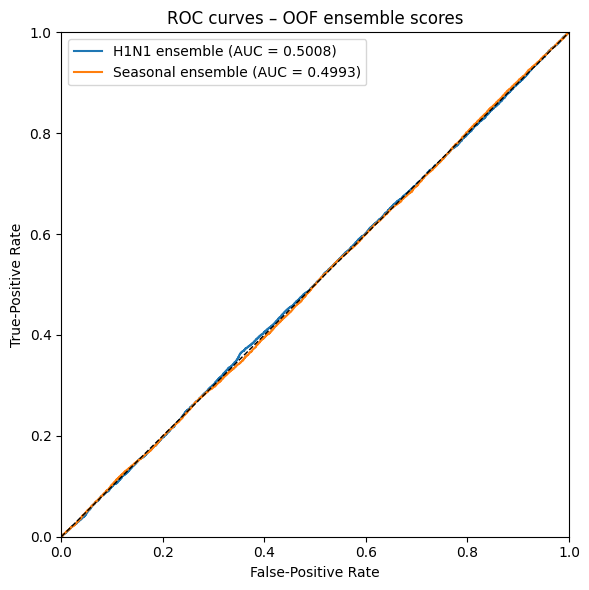

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(6, 6))

# --- H1N1
fpr_h1, tpr_h1, _ = roc_curve(y_h1n1, h1n1_final[:26707])
auc_h1            = roc_auc_score(y_h1n1, h1n1_final[:26707])
ax.plot(fpr_h1, tpr_h1, label=f"H1N1 ensemble (AUC = {auc_h1:.4f})")

# --- Seasonal
fpr_sea, tpr_sea, _ = roc_curve(y_seasonal, seasonal_final[:26707])
auc_sea            = roc_auc_score(y_seasonal, seasonal_final[:26707])
ax.plot(fpr_sea, tpr_sea, label=f"Seasonal ensemble (AUC = {auc_sea:.4f})")

# --- Formatting
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False-Positive Rate")
ax.set_ylabel("True-Positive Rate")
ax.set_title("ROC curves – OOF ensemble scores")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
# # Install required libraries
# !pip install catboost ngboost scikit-learn pandas numpy --quiet

# # ✅ Import necessary libraries
# import numpy as np
# import pandas as pd
# from catboost import CatBoostClassifier
# from ngboost import NGBClassifier
# from ngboost.learners import default_tree_learner
# from ngboost.distns import Bernoulli
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.ensemble import HistGradientBoostingClassifier
# from sklearn.metrics import roc_auc_score, log_loss

# # # ✅ Drop respondent_id from features
# # X = training_data_selected.drop(columns=['h1n1_vaccine', 'seasonal_vaccine'])
# # test_data_encoded = test_data_encoded.drop(columns=['respondent_id'], errors='ignore')

# # # ✅ Define target variables
# # y_h1n1 = training_data_selected['h1n1_vaccine']
# # y_seasonal = training_data_selected['seasonal_vaccine']

# # # ✅ Split Data into Training & Validation Sets (80-20 split)
# # X_train, X_valid, y_train_h1n1, y_valid_h1n1 = train_test_split(X, y_h1n1, test_size=0.2, random_state=42)
# # X_train, X_valid, y_train_seasonal, y_valid_seasonal = train_test_split(X, y_seasonal, test_size=0.2, random_state=42)

# # # ✅ Handle Missing Values
# # imputer = SimpleImputer(strategy="mean")
# # X_train_imputed = imputer.fit_transform(X_train)
# # X_valid_imputed = imputer.transform(X_valid)
# # test_data_fixed = test_data_encoded
# # test_data_imputed = imputer.transform(test_data_fixed)

# # # ✅ Scale Data for NGBoost & HistGB (CatBoost does not need scaling)
# # scaler = StandardScaler()
# # X_train_scaled = scaler.fit_transform(X_train_imputed)
# # X_valid_scaled = scaler.transform(X_valid_imputed)
# # test_data_scaled = scaler.transform(test_data_imputed)

# # 🚀 **Train HistGradientBoostingClassifier**
# def train_histgb(X_train, y_train, X_valid, y_valid, vaccine_type):
#     model = HistGradientBoostingClassifier(
#         max_iter=200, learning_rate=0.05, max_depth=6, min_samples_leaf=20, random_state=42
#     )
#     model.fit(X_train, y_train)
#     probs = model.predict_proba(X_valid)[:, 1]
#     auc = roc_auc_score(y_valid, probs)
#     logloss = log_loss(y_valid, probs)
#     print(f"\n🔹 HistGB Results for {vaccine_type}: AUC: {auc:.5f} | Log Loss: {logloss:.5f}")
#     return model, auc

# print("\n🚀 Training HistGradientBoostingClassifier...")
# histgb_h1n1, auc_histgb_h1n1 = train_histgb(X_h1n1_scaled, y_train_h1n1, X_h1n1, y_valid_h1n1, "H1N1 Vaccine")
# histgb_seasonal, auc_histgb_seasonal = train_histgb(X_seasonal_scaled, y_train_seasonal, X_seasonal, y_valid_seasonal, "Seasonal Vaccine")

# # 🚀 **Train CatBoost**
# print("\n🚀 Training CatBoost...")
# h1n1_catboost = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, loss_function='Logloss', verbose=100, random_state=42)
# seasonal_catboost = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, loss_function='Logloss', verbose=100, random_state=42)

# h1n1_catboost.fit(X_train_h1n1, y_train_h1n1)
# seasonal_catboost.fit(X_train_seasonal, y_train_seasonal)

# h1n1_catboost_probs = h1n1_catboost.predict_proba(X_valid_h1n1)[:, 1]
# seasonal_catboost_probs = seasonal_catboost.predict_proba(X_valid_seasonal)[:, 1]

# auc_catboost_h1n1 = roc_auc_score(y_valid_h1n1, h1n1_catboost_probs)
# auc_catboost_seasonal = roc_auc_score(y_valid_seasonal, seasonal_catboost_probs)

# print("\n🔹 CatBoost Results:")
# print("H1N1 Vaccine - AUC-ROC:", auc_catboost_h1n1)
# print("Seasonal Vaccine - AUC-ROC:", auc_catboost_seasonal)

# # 🚀 **Train NGBoost**
# def train_ngboost(X_train, y_train, X_valid, y_valid, vaccine_type):
#     model = NGBClassifier(
#         Dist=Bernoulli, Base=default_tree_learner, n_estimators=500, learning_rate=0.05, minibatch_frac=0.8, random_state=42
#     )
#     model.fit(X_train, y_train)
#     probs = model.predict_proba(X_valid)[:, 1]
#     auc = roc_auc_score(y_valid, probs)
#     logloss = log_loss(y_valid, probs)
#     print(f"\n🔹 NGBoost Results for {vaccine_type}: AUC: {auc:.5f} | Log Loss: {logloss:.5f}")
#     return model, auc

# print("\n🚀 Training NGBoost...")
# ngboost_h1n1, auc_ngboost_h1n1 = train_ngboost(X_h1n1_scaled, y_train_h1n1, X_h1n1, y_valid_h1n1, "H1N1 Vaccine")
# ngboost_seasonal, auc_ngboost_seasonal = train_ngboost(X_seasonal_scaled, y_train_seasonal, X_seasonal, y_valid_seasonal, "Seasonal Vaccine")
# from sklearn.ensemble import RandomForestClassifier

# # ✅ Train Random Forest with best-tuned params
# rf_h1n1 = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=None,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     random_state=42
# )
# rf_seasonal = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=10,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     random_state=42
# )

# rf_h1n1.fit(X_train_h1n1, y_train_h1n1)
# rf_seasonal.fit(X_train_seasonal, y_train_seasonal)

# rf_probs_h1n1 = rf_h1n1.predict_proba(X_valid_h1n1)[:, 1]
# rf_probs_seasonal = rf_seasonal.predict_proba(X_valid_seasonal)[:, 1]

# auc_rf_h1n1 = roc_auc_score(y_valid_h1n1, rf_probs_h1n1)
# auc_rf_seasonal = roc_auc_score(y_valid_seasonal, rf_probs_seasonal)

# print("\n🔹 Random Forest (Tuned) Results:")
# print("H1N1 Vaccine - AUC-ROC:", auc_rf_h1n1)
# print("Seasonal Vaccine - AUC-ROC:", auc_rf_seasonal)

# # ✅ Update weights to include RF
# total_auc_h1n1 = auc_histgb_h1n1 + auc_catboost_h1n1 + auc_ngboost_h1n1 + auc_rf_h1n1
# weight_h1n1_rf = auc_rf_h1n1 / total_auc_h1n1
# weight_h1n1_histgb = auc_histgb_h1n1 / total_auc_h1n1
# weight_h1n1_catboost = auc_catboost_h1n1 / total_auc_h1n1
# weight_h1n1_ngboost = auc_ngboost_h1n1 / total_auc_h1n1

# total_auc_seasonal = auc_histgb_seasonal + auc_catboost_seasonal + auc_ngboost_seasonal + auc_rf_seasonal
# weight_seasonal_rf = auc_rf_seasonal / total_auc_seasonal
# weight_seasonal_histgb = auc_histgb_seasonal / total_auc_seasonal
# weight_seasonal_catboost = auc_catboost_seasonal / total_auc_seasonal
# weight_seasonal_ngboost = auc_ngboost_seasonal / total_auc_seasonal

# # ✅ Final Ensemble: 4-model weighted prediction
# h1n1_test_probs = (
#     weight_h1n1_histgb * histgb_h1n1.predict_proba(test_scaled)[:, 1] +
#     weight_h1n1_catboost * h1n1_catboost.predict_proba(test_scaled)[:, 1] +
#     weight_h1n1_ngboost * ngboost_h1n1.predict_proba(test_scaled)[:, 1] +
#     weight_h1n1_rf * rf_h1n1.predict_proba(test_scaled)[:, 1]
# )

# seasonal_test_probs = (
#     weight_seasonal_histgb * histgb_seasonal.predict_proba(test_scaled)[:, 1] +
#     weight_seasonal_catboost * seasonal_catboost.predict_proba(test_scaled)[:, 1] +
#     weight_seasonal_ngboost * ngboost_seasonal.predict_proba(test_scaled)[:, 1] +
#     weight_seasonal_rf * rf_seasonal.predict_proba(test_scaled)[:, 1]
# )

# # ✅ Clip to valid probability range
# h1n1_test_probs = np.clip(h1n1_test_probs, 0, 1)
# seasonal_test_probs = np.clip(seasonal_test_probs, 0, 1)



In [15]:
# # ✅ Create submission again
# submission_df = pd.DataFrame({
#     "respondent_id": test_data['respondent_id'],
#     "h1n1_vaccine": h1n1_test_probs,
#     "seasonal_vaccine": seasonal_test_probs
# })

# submission_df.to_csv("submission_ensemble_4models.csv", index=False)
# print("\n✅ Submission file saved as 'submission_ensemble_4models.csv' 🧠📊")


In [16]:
# # with CV
# !pip install tensorflow
# # !pip install --force-reinstall catboost
# # !pip install catboost ngboost scikit-learn pandas numpy --quiet

# import numpy as np
# import pandas as pd
# from catboost import CatBoostClassifier
# from ngboost import NGBClassifier
# from ngboost.learners import default_tree_learner
# from ngboost.distns import Bernoulli
# from sklearn.model_selection import StratifiedKFold
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
# from sklearn.metrics import roc_auc_score
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.utils import to_categorical

# # Stratified K-Fold
# N_FOLDS = 5
# skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# def cross_val_model(model_fn, X, y, X_test, model_name):
#     oof_preds = np.zeros(len(y))
#     test_preds = np.zeros(X_test.shape[0])
#     aucs = []

#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_tr, X_val = X[train_idx], X[val_idx]
#         y_tr, y_val = y[train_idx], y[val_idx]

#         model = model_fn()
#         model.fit(X_tr, y_tr)

#         val_probs = model.predict_proba(X_val)[:, 1]
#         test_probs = model.predict_proba(X_test)[:, 1]

#         oof_preds[val_idx] = val_probs
#         test_preds += test_probs / N_FOLDS

#         auc = roc_auc_score(y_val, val_probs)
#         aucs.append(auc)
#         print(f"📊 Fold {fold+1} AUC ({model_name}): {auc:.5f}")

#     print(f"✅ Mean AUC for {model_name}: {np.mean(aucs):.5f}")
#     return test_preds, np.mean(aucs)

# # Function to create the neural network model
# def create_nn_model(input_shape):
#     model = Sequential()
#     model.add(Dense(64, input_dim=input_shape, activation='relu'))
#     model.add(Dropout(0.3))
#     model.add(Dense(32, activation='relu'))
#     model.add(Dropout(0.3))
#     model.add(Dense(1, activation='sigmoid'))  # Binary classification for vaccine prediction
#     model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['AUC'])
#     return model

# def cross_val_nn_model(model_fn, X, y, X_test, model_name):
#     oof_preds = np.zeros(len(y))
#     test_preds = np.zeros(X_test.shape[0])
#     aucs = []

#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_tr, X_val = X[train_idx], X[val_idx]
#         y_tr, y_val = y[train_idx], y[val_idx]

#         # Reshape for neural network
#         X_tr = X_tr.astype('float32')
#         X_val = X_val.astype('float32')
#         X_test_nn = X_test.astype('float32')

#         model = model_fn(X_tr.shape[1])  # Input shape
#         model.fit(X_tr, y_tr, epochs=10, batch_size=64, validation_data=(X_val, y_val), verbose=0)

#         val_probs = model.predict(X_val).flatten()
#         test_probs = model.predict(X_test_nn).flatten()

#         oof_preds[val_idx] = val_probs
#         test_preds += test_probs / N_FOLDS

#         auc = roc_auc_score(y_val, val_probs)
#         aucs.append(auc)
#         print(f"📊 Fold {fold+1} AUC ({model_name}): {auc:.5f}")

#     print(f"✅ Mean AUC for {model_name}: {np.mean(aucs):.5f}")
#     return test_preds, np.mean(aucs)

# # Model wrappers
# histgb_fn = lambda: HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=6, min_samples_leaf=20, random_state=42)
# catboost_fn = lambda: CatBoostClassifier(iterations=500, learning_rate=0.05745075659543725, depth=6, loss_function='Logloss', verbose=0, random_strength=4,
#     bagging_temperature=8,
#     max_bin=5,
#     grow_policy= "Lossguide",
#     min_data_in_leaf=7,
#     l2_leaf_reg=11.323094517862078,
#     one_hot_max_size=10,
#     auto_class_weights="Balanced", random_state=42)
# ngboost_fn = lambda: NGBClassifier(Dist=Bernoulli, Base=default_tree_learner, n_estimators=500, learning_rate=0.05, minibatch_frac=0.8, random_state=42)
# rf_h1n1_fn = lambda: RandomForestClassifier(n_estimators=600, max_depth=18, min_samples_split=5, min_samples_leaf=2, random_state=42)
# rf_season_fn = lambda: RandomForestClassifier(n_estimators=600, max_depth=18, min_samples_split=5, min_samples_leaf=2, random_state=42)
# nn_fn = lambda input_shape: create_nn_model(input_shape)

# # H1N1 CV
# histgb_h1n1_pred, auc_histgb_h1n1 = cross_val_model(histgb_fn, X_h1n1_scaled, y_h1n1.values, test_scaled, "HistGB-H1N1")
# catboost_h1n1_pred, auc_catboost_h1n1 = cross_val_model(catboost_fn, X_h1n1, y_h1n1.values, test_unscaled, "CatBoost-H1N1")
# ngboost_h1n1_pred, auc_ngboost_h1n1 = cross_val_model(ngboost_fn, X_h1n1_scaled, y_h1n1.values, test_scaled, "NGBoost-H1N1")
# rf_h1n1_pred, auc_rf_h1n1 = cross_val_model(rf_h1n1_fn, X_h1n1, y_h1n1.values, test_unscaled, "RandomForest-H1N1")
# nn_h1n1_pred, auc_nn_h1n1 = cross_val_nn_model(nn_fn, X_h1n1_scaled, y_h1n1.values, test_scaled, "NeuralNetwork-H1N1")

# # Seasonal CV
# histgb_seasonal_pred, auc_histgb_seasonal = cross_val_model(histgb_fn, X_seasonal_scaled, y_seasonal.values, test_scaled, "HistGB-Seasonal")
# catboost_seasonal_pred, auc_catboost_seasonal = cross_val_model(catboost_fn, X_seasonal, y_seasonal.values, test_unscaled, "CatBoost-Seasonal")
# ngboost_seasonal_pred, auc_ngboost_seasonal = cross_val_model(ngboost_fn, X_seasonal_scaled, y_seasonal.values, test_scaled, "NGBoost-Seasonal")
# rf_seasonal_pred, auc_rf_seasonal = cross_val_model(rf_season_fn, X_seasonal, y_seasonal.values, test_unscaled, "RandomForest-Seasonal")
# nn_seasonal_pred, auc_nn_seasonal = cross_val_nn_model(nn_fn, X_seasonal_scaled, y_seasonal.values, test_scaled, "NeuralNetwork-Seasonal")

# # AUC-weighted ensemble with neural network
# total_auc_h1n1 = auc_histgb_h1n1 + auc_catboost_h1n1 + auc_ngboost_h1n1 + auc_rf_h1n1 + auc_nn_h1n1
# h1n1_final = (
#     (auc_histgb_h1n1 / total_auc_h1n1) * histgb_h1n1_pred +
#     (auc_catboost_h1n1 / total_auc_h1n1) * catboost_h1n1_pred +
#     (auc_ngboost_h1n1 / total_auc_h1n1) * ngboost_h1n1_pred +
#     (auc_rf_h1n1 / total_auc_h1n1) * rf_h1n1_pred +
#     (auc_nn_h1n1 / total_auc_h1n1) * nn_h1n1_pred
# )

# total_auc_seasonal = auc_histgb_seasonal + auc_catboost_seasonal + auc_ngboost_seasonal + auc_rf_seasonal + auc_nn_seasonal
# seasonal_final = (
#     (auc_histgb_seasonal / total_auc_seasonal) * histgb_seasonal_pred +
#     (auc_catboost_seasonal / total_auc_seasonal) * catboost_seasonal_pred +
#     (auc_ngboost_seasonal / total_auc_seasonal) * ngboost_seasonal_pred +
#     (auc_rf_seasonal / total_auc_seasonal) * rf_seasonal_pred +
#     (auc_nn_seasonal / total_auc_seasonal) * nn_seasonal_pred
# )

# # Submission
# import pandas as pd
# submission_df = pd.DataFrame({
#     "respondent_id": test_data["respondent_id"],
#     "h1n1_vaccine": np.clip(h1n1_final, 0, 1),
#     "seasonal_vaccine": np.clip(seasonal_final, 0, 1)
# })

# submission_df.to_csv("submission_cv_ensemble3_NN.csv", index=False)
# print("\n✅ Submission file saved as 'submission_cv_ensemble3_with_NN.csv' 🧠📊")

In [17]:
# import numpy as np
# import pandas as pd
# from catboost import CatBoostClassifier
# from ngboost import NGBClassifier
# from ngboost.learners import default_tree_learner
# from ngboost.distns import Bernoulli
# from sklearn.model_selection import StratifiedKFold
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
# from sklearn.metrics import roc_auc_score
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam

# # Step 1: Data Preprocessing
# # Assuming you have `training_data_encoded` and `test_data_encoded` preloaded

# # Drop unnecessary columns and separate features and targets
# X = training_data_selected.drop(columns=['h1n1_vaccine', 'seasonal_vaccine'])
# y_h1n1 = training_data_selected['h1n1_vaccine']
# y_seasonal = training_data_selected['seasonal_vaccine']
# test_data = test_data_encoded.drop(columns=['respondent_id'], errors='ignore')

# # Impute missing values and scale the features
# imputer = SimpleImputer(strategy="mean")
# scaler = StandardScaler()

# # For H1N1 and Seasonal: Impute and scale the data
# X_h1n1_scaled = scaler.fit_transform(imputer.fit_transform(X))
# X_seasonal_scaled = scaler.fit_transform(imputer.fit_transform(X))

# # Same for the test set
# # test_scaled = scaler.transform(imputer.transform(test_data))

# # Step 2: Define Cross-Validation with StratifiedKFold
# N_FOLDS = 5
# skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# # Step 3: Define Neural Network Model
# def create_nn_model(input_shape):
#     model = Sequential()
#     model.add(Dense(64, input_dim=input_shape, activation='relu'))
#     model.add(Dropout(0.3))
#     model.add(Dense(32, activation='relu'))
#     model.add(Dropout(0.3))
#     model.add(Dense(1, activation='sigmoid'))  # Binary classification for vaccine prediction
#     model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['AUC'])
#     return model

# # Step 4: Define Cross-Validation Function for All Models
# def cross_val_model(model_fn, X, y, X_test, model_name):
#     oof_preds = np.zeros(len(y))
#     test_preds = np.zeros(X_test.shape[0])
#     aucs = []

#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_tr, X_val = X[train_idx], X[val_idx]
#         y_tr, y_val = y[train_idx], y[val_idx]

#         # Train the model
#         model = model_fn()
#         model.fit(X_tr, y_tr)

#         # Make predictions
#         val_probs = model.predict_proba(X_val)[:, 1]
#         test_probs = model.predict_proba(X_test)[:, 1]

#         # Store predictions
#         oof_preds[val_idx] = val_probs
#         test_preds += test_probs / N_FOLDS

#         auc = roc_auc_score(y_val, val_probs)
#         aucs.append(auc)
#         print(f"📊 Fold {fold+1} AUC ({model_name}): {auc:.5f}")

#     print(f"✅ Mean AUC for {model_name}: {np.mean(aucs):.5f}")
#     return test_preds, np.mean(aucs)

# # Step 5: Model Wrappers for Traditional Models
# histgb_fn = lambda: HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=6, min_samples_leaf=20, random_state=42)
# catboost_fn = lambda: CatBoostClassifier(iterations=500, learning_rate=0.057, depth=6, loss_function='Logloss', verbose=0, random_state=42)
# ngboost_fn = lambda: NGBClassifier(Dist=Bernoulli, Base=default_tree_learner, n_estimators=500, learning_rate=0.05, minibatch_frac=0.8, random_state=42)
# rf_h1n1_fn = lambda: RandomForestClassifier(n_estimators=600, max_depth=18, min_samples_split=5, min_samples_leaf=2, random_state=42)
# rf_season_fn = lambda: RandomForestClassifier(n_estimators=600, max_depth=18, min_samples_split=5, min_samples_leaf=2, random_state=42)

# # Step 6: Model Wrappers for Neural Network
# def cross_val_nn_model(model_fn, X, y, X_test, model_name):
#     oof_preds = np.zeros(len(y))
#     test_preds = np.zeros(X_test.shape[0])
#     aucs = []

#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_tr, X_val = X[train_idx], X[val_idx]
#         y_tr, y_val = y[train_idx], y[val_idx]

#         # Reshape for neural network
#         X_tr = X_tr.astype('float32')
#         X_val = X_val.astype('float32')
#         X_test_nn = X_test.astype('float32')

#         model = model_fn(X_tr.shape[1])  # Input shape
#         model.fit(X_tr, y_tr, epochs=10, batch_size=64, validation_data=(X_val, y_val), verbose=0)

#         val_probs = model.predict(X_val).flatten()
#         test_probs = model.predict(X_test_nn).flatten()

#         oof_preds[val_idx] = val_probs
#         test_preds += test_probs / N_FOLDS

#         auc = roc_auc_score(y_val, val_probs)
#         aucs.append(auc)
#         print(f"📊 Fold {fold+1} AUC ({model_name}): {auc:.5f}")

#     print(f"✅ Mean AUC for {model_name}: {np.mean(aucs):.5f}")
#     return test_preds, np.mean(aucs)

# # Step 7: Cross-Validation for H1N1 and Seasonal Models (Including Neural Network)
# # H1N1 CV
# histgb_h1n1_pred, auc_histgb_h1n1 = cross_val_model(histgb_fn, X_h1n1_scaled, y_h1n1.values, test_scaled, "HistGB-H1N1")
# catboost_h1n1_pred, auc_catboost_h1n1 = cross_val_model(catboost_fn, X_h1n1, y_h1n1.values, test_scaled, "CatBoost-H1N1")
# ngboost_h1n1_pred, auc_ngboost_h1n1 = cross_val_model(ngboost_fn, X_h1n1_scaled, y_h1n1.values, test_scaled, "NGBoost-H1N1")
# rf_h1n1_pred, auc_rf_h1n1 = cross_val_model(rf_h1n1_fn, X_h1n1, y_h1n1.values, test_scaled, "RandomForest-H1N1")
# nn_h1n1_pred, auc_nn_h1n1 = cross_val_nn_model(create_nn_model, X_h1n1_scaled, y_h1n1.values, test_scaled, "NeuralNetwork-H1N1")

# # Seasonal CV
# histgb_seasonal_pred, auc_histgb_seasonal = cross_val_model(histgb_fn, X_seasonal_scaled, y_seasonal.values, test_scaled, "HistGB-Seasonal")
# catboost_seasonal_pred, auc_catboost_seasonal = cross_val_model(catboost_fn, X_seasonal, y_seasonal.values, test_scaled, "CatBoost-Seasonal")
# ngboost_seasonal_pred, auc_ngboost_seasonal = cross_val_model(ngboost_fn, X_seasonal_scaled, y_seasonal.values, test_scaled, "NGBoost-Seasonal")
# rf_seasonal_pred, auc_rf_seasonal = cross_val_model(rf_season_fn, X_seasonal, y_seasonal.values, test_scaled, "RandomForest-Seasonal")
# nn_seasonal_pred, auc_nn_seasonal = cross_val_nn_model(create_nn_model, X_seasonal_scaled, y_seasonal.values, test_scaled, "NeuralNetwork-Seasonal")

# # Step 8: AUC-weighted Ensemble for Final Prediction
# # H1N1 Final Prediction
# total_auc_h1n1 = auc_histgb_h1n1 + auc_catboost_h1n1 + auc_ngboost_h1n1 + auc_rf_h1n1 + auc_nn_h1n1
# h1n1_final = (
#     (auc_histgb_h1n1 / total_auc_h1n1) * histgb_h1n1_pred +
#     (auc_catboost_h1n1 / total_auc_h1n1) * catboost_h1n1_pred +
#     (auc_ngboost_h1n1 / total_auc_h1n1) * ngboost_h1n1_pred +
#     (auc_rf_h1n1 / total_auc_h1n1) * rf_h1n1_pred +
#     (auc_nn_h1n1 / total_auc_h1n1) * nn_h1n1_pred
# )

# # Seasonal Final Prediction
# total_auc_seasonal = auc_histgb_seasonal + auc_catboost_seasonal + auc_ngboost_seasonal + auc_rf_seasonal + auc_nn_seasonal
# seasonal_final = (
#     (auc_histgb_seasonal / total_auc_seasonal) * histgb_seasonal_pred +
#     (auc_catboost_seasonal / total_auc_seasonal) * catboost_seasonal_pred +
#     (auc_ngboost_seasonal / total_auc_seasonal) * ngboost_seasonal_pred +
#     (auc_rf_seasonal / total_auc_seasonal) * rf_seasonal_pred +
#     (auc_nn_seasonal / total_auc_seasonal) * nn_seasonal_pred
# )

# # Step 9: Final Submission
# submission_df = pd.DataFrame({
#     "respondent_id": test_data1["respondent_id"],
#     "h1n1_vaccine": np.clip(h1n1_final, 0, 1),
#     "seasonal_vaccine": np.clip(seasonal_final, 0, 1)
# })

# submission_df.to_csv("submission_cv_ensemble_nn.csv", index=False)
# print("\n✅ Submission file saved as 'submission_cv_ensemble_nn.csv' 🧠📊")


In [18]:
# # !pip install --force-reinstall catboost

# from catboost import CatBoostClassifier
# from sklearn.metrics import roc_auc_score, log_loss
# from sklearn.model_selection import train_test_split


# cat_features = ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status',
#                 'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa']
# label_encoders_cb = {}

# for col in cat_features:
#     le = LabelEncoder()
#     trainData[col] = le.fit_transform(trainData[col].astype(str))
#     label_encoders_cb[col] = le

# # ---------------------- 7️⃣ Feature Selection ----------------------
# top_features = [
#     'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_seas_sick_from_vacc',
#     'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'h1n1_concern',
#     'opinion_seas_risk', 'health_worker', 'h1n1_knowledge', 'household_children',
#     'household_adults', 'doctor_recc_seasonal', 'doctor_recc_h1n1',
#     'behavioral_large_gatherings', 'census_msa',
#     'age_group', 'sex', 'education', 'marital_status'
# ]

# target_cols = ['h1n1_vaccine', 'seasonal_vaccine']
# final_features = list(set(top_features + target_cols))
# training_data_selected = trainData[final_features]

# # ---------------------- 8️⃣ Train/Validation Split ----------------------
# X = training_data_selected.drop(columns=target_cols)
# y_h1n1 = training_data_selected['h1n1_vaccine']
# y_seasonal = training_data_selected['seasonal_vaccine']

# X_train, X_valid, y_train_h1n1, y_valid_h1n1 = train_test_split(X, y_h1n1, test_size=0.2, random_state=42)
# X_train, X_valid, y_train_seasonal, y_valid_seasonal = train_test_split(X, y_seasonal, test_size=0.2, random_state=42)

# cat_feature_indices = [X.columns.get_loc(col) for col in cat_features if col in X.columns]

# # ---------------------- 9️⃣ Train CatBoost Models ----------------------
# h1n1_model = CatBoostClassifier(iterations=325, learning_rate=0.05, depth=6,
#                                 loss_function='Logloss', cat_features=cat_feature_indices,
#                                 verbose=100, random_seed=42)
# seasonal_model = CatBoostClassifier(iterations=325, learning_rate=0.05, depth=6,
#                                     loss_function='Logloss', cat_features=cat_feature_indices,
#                                     verbose=100, random_seed=42)

# h1n1_model.fit(X_train, y_train_h1n1, eval_set=(X_valid, y_valid_h1n1), early_stopping_rounds=50)
# seasonal_model.fit(X_train, y_train_seasonal, eval_set=(X_valid, y_valid_seasonal), early_stopping_rounds=50)

# # ---------------------- 🔟 Prepare Test Data ----------------------
# for col in cat_features:
#     if col in test_data.columns:
#         test_data[col] = test_data[col].astype(str).apply(lambda x: x if x in label_encoders_cb[col].classes_ else 'Unknown')
#         label_encoders_cb[col].classes_ = np.append(label_encoders_cb[col].classes_, 'Unknown')
#         test_data[col] = label_encoders_cb[col].transform(test_data[col])

# # Ensure test set has all columns
# for col in X.columns:
#     if col not in test_data.columns:
#         test_data[col] = 0
# test_data_encoded = test_data[X.columns]

# # ---------------------- 🧾 Generate Predictions ----------------------
# h1n1_probs = h1n1_model.predict_proba(test_data_encoded)[:, 1]
# seasonal_probs = seasonal_model.predict_proba(test_data_encoded)[:, 1]

# submission = pd.DataFrame({
#     'respondent_id': test_data['respondent_id'],
#     'h1n1_vaccine': h1n1_probs,
#     'seasonal_vaccine': seasonal_probs
# })
# submission.to_csv("submission_catboost_smaller_knn.csv", index=False)
# print("✅ Submission saved as 'submission_catboost_smaller_knn.csv'")

In [19]:
# # # ---------------------- 📦 Imports ----------------------
# # import pandas as pd
# # import numpy as np
# # from sklearn.impute import KNNImputer
# # from sklearn.preprocessing import LabelEncoder
# # from sklearn.model_selection import train_test_split, GridSearchCV
# # from sklearn.ensemble import RandomForestClassifier
# # from sklearn.metrics import roc_auc_score, log_loss

# # ---------------------- 1️⃣ Load Data ----------------------
# train_features = pd.read_csv("/content/training_set_features.csv")
# train_labels = pd.read_csv("/content/training_set_labels.csv")
# test_data = pd.read_csv("/content/test_set_features.csv")

# # Merge features and labels for training
# training_data = pd.merge(train_features, train_labels, on='respondent_id')

# # ---------------------- 2️⃣ Handle Missing Values ----------------------
# threshold = 10
# training_data_cleaned = training_data.drop(training_data[training_data.isnull().sum(axis=1) > threshold].index)

# # ---------------------- 3️⃣ Fill Missing Values ----------------------
# age_groups = ['55 - 64 Years', '45 - 54 Years', '35 - 44 Years', '18 - 34 Years', '65+ Years']
# for age_group in age_groups:
#     mode_edu = training_data_cleaned.loc[training_data_cleaned['age_group'] == age_group, 'education'].mode()
#     if not mode_edu.empty:
#         training_data_cleaned.loc[
#             (training_data_cleaned['age_group'] == age_group) &
#             (training_data_cleaned['education'].isnull()),
#             'education'
#         ] = mode_edu[0]

# def update_employment_status(df):
#     for idx, row in df.iterrows():
#         if pd.isnull(row['employment_status']):
#             df.at[idx, 'employment_status'] = 'Not in Labor Force' if row['age_group'] == '65+ Years' else 'Unemployed'
#     return df
# training_data_cleaned = update_employment_status(training_data_cleaned)

# # ---------------------- 4️⃣ Label Encode for KNN Imputation ----------------------
# categorical_features = ['education', 'employment_status', 'race', 'sex', 'hhs_geo_region', 'census_msa', 'age_group']
# label_encoders = {}
# for col in categorical_features:
#     le = LabelEncoder()
#     training_data_cleaned[col] = le.fit_transform(training_data_cleaned[col].astype(str))
#     label_encoders[col] = le

# income_mapping = {
#     "> $75,000": 2,
#     "<= $75,000, Above Poverty": 1,
#     "Below Poverty": 0
# }
# training_data_cleaned['income_poverty'] = training_data_cleaned['income_poverty'].map(income_mapping)

# # ---------------------- 5️⃣ kNN Imputation ----------------------
# knn_features = ['income_poverty', 'education', 'employment_status', 'age_group',
#                 'race', 'sex', 'hhs_geo_region', 'census_msa']
# knn_imputer = KNNImputer(n_neighbors=3)
# training_data_cleaned[knn_features] = knn_imputer.fit_transform(training_data_cleaned[knn_features])

# training_data_cleaned['income_poverty'] = training_data_cleaned['income_poverty'].round().astype(int).map({v: k for k, v in income_mapping.items()})
# for col in categorical_features:
#     training_data_cleaned[col] = label_encoders[col].inverse_transform(training_data_cleaned[col].astype(int))

# # ---------------------- 6️⃣ Fill Remaining Nulls ----------------------
# binary_columns = [
#     'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
#     'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
#     'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
#     'chronic_med_condition', 'child_under_6_months', 'health_worker'
# ]
# for col in binary_columns:
#     training_data_cleaned[col] = training_data_cleaned[col].fillna(training_data_cleaned[col].mode()[0])

# scaled_columns = [
#     'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
#     'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
#     'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc'
# ]
# for col in scaled_columns:
#     training_data_cleaned[col] = training_data_cleaned[col].fillna(training_data_cleaned[col].mode()[0])

# training_data_cleaned['marital_status'] = training_data_cleaned['marital_status'].fillna(training_data_cleaned['marital_status'].mode()[0])
# training_data_cleaned['rent_or_own'] = training_data_cleaned['rent_or_own'].fillna(training_data_cleaned['rent_or_own'].mode()[0])
# training_data_cleaned['household_adults'] = training_data_cleaned['household_adults'].fillna(training_data_cleaned['household_adults'].median())
# training_data_cleaned['household_children'] = training_data_cleaned['household_children'].fillna(training_data_cleaned['household_children'].median())

# # ---------------------- 7️⃣ One-Hot Encoding ----------------------
# onehot_features = ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status',
#                    'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa']
# training_data_encoded = pd.get_dummies(training_data_cleaned, columns=onehot_features, drop_first=True)

# # Label encode employment features
# for col in ['employment_industry', 'employment_occupation']:
#     le = LabelEncoder()
#     training_data_encoded[col] = le.fit_transform(training_data_cleaned[col].astype(str))

# '''
# # ---------------------- 8️⃣ Train Random Forest with Hyperparameter Tuning ----------------------
# X = training_data_encoded.drop(columns=['h1n1_vaccine', 'seasonal_vaccine'])
# y_h1n1 = training_data_encoded['h1n1_vaccine']
# y_seasonal = training_data_encoded['seasonal_vaccine']

# X_train, X_valid, y_train_h1n1, y_valid_h1n1 = train_test_split(X, y_h1n1, test_size=0.2, random_state=42)
# X_train, X_valid, y_train_seasonal, y_valid_seasonal = train_test_split(X, y_seasonal, test_size=0.2, random_state=42)


# # Define param grid
# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [6, 10, None],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'random_state': [42]
# }


# # Grid Search for H1N1
# grid_h1n1 = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='roc_auc', verbose=1, n_jobs=-1)
# grid_h1n1.fit(X_train, y_train_h1n1)

# # Grid Search for Seasonal
# grid_seasonal = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='roc_auc', verbose=1, n_jobs=-1)
# grid_seasonal.fit(X_train, y_train_seasonal)

# # Best Models
# h1n1_best = grid_h1n1.best_estimator_
# seasonal_best = grid_seasonal.best_estimator_

# # Validation Predictions
# h1n1_probs_val = h1n1_best.predict_proba(X_valid)[:, 1]
# seasonal_probs_val = seasonal_best.predict_proba(X_valid)[:, 1]

# # Evaluation
# print("🔍 Best Params for H1N1:", grid_h1n1.best_params_)
# print("H1N1 AUC:", roc_auc_score(y_valid_h1n1, h1n1_probs_val))
# print("H1N1 Log Loss:", log_loss(y_valid_h1n1, h1n1_probs_val))

# print("🔍 Best Params for Seasonal:", grid_seasonal.best_params_)
# print("Seasonal AUC:", roc_auc_score(y_valid_seasonal, seasonal_probs_val))
# print("Seasonal Log Loss:", log_loss(y_valid_seasonal, seasonal_probs_val))

# # ---------------------- 9️⃣ Prepare Test Data ----------------------
# test_data_encoded = pd.get_dummies(test_data, columns=onehot_features, drop_first=True)
# for col in X.columns:
#     if col not in test_data_encoded.columns:
#         test_data_encoded[col] = 0
# test_data_encoded = test_data_encoded[X.columns]

# # Encode employment columns
# for col in ['employment_industry', 'employment_occupation']:
#     le = LabelEncoder()
#     le.fit(training_data_cleaned[col].astype(str))
#     test_data_encoded[col] = le.transform(test_data[col].astype(str))

# # Predictions on Test Set
# h1n1_test_probs = h1n1_best.predict_proba(test_data_encoded)[:, 1]
# seasonal_test_probs = seasonal_best.predict_proba(test_data_encoded)[:, 1]

# # ---------------------- 🔟 Submission File ----------------------
# submission_df = pd.DataFrame({
#     "respondent_id": test_data["respondent_id"],
#     "h1n1_vaccine": h1n1_test_probs,
#     "seasonal_vaccine": seasonal_test_probs
# })
# submission_df.to_csv("submission_random_forest_tuned.csv", index=False)
# print("✅ Submission file saved as 'submission_random_forest_tuned.csv'")
# '''

In [20]:
# # ============================================================
# # 📦 1. Imports & one‑time installs
# # ============================================================
# !pip install iterative-stratification -q    # only needed once per runtime

# import pandas as pd
# import numpy as np
# from sklearn.impute import KNNImputer
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import roc_auc_score
# from sklearn.ensemble import RandomForestClassifier
# from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
# from pathlib import Path

# # ============================================================
# # 2. Load data
# # ============================================================
# train_feat = pd.read_csv("/content/training_set_features.csv")
# train_lab = pd.read_csv("/content/training_set_labels.csv")
# test_feat = pd.read_csv("/content/test_set_features.csv")

# df = train_feat.merge(train_lab, on="respondent_id")

# # ============================================================
# # 3. Light cleaning / imputations  (RE‑USING your logic)
# # ============================================================
# # --- 3.1 drop rows with too many NaNs
# row_nan_thresh = 10
# df = df.drop(df[df.isnull().sum(axis=1) > row_nan_thresh].index)

# # --- 3.2 age‑group‑specific fills for education
# for ag in df["age_group"].unique():
#     mode_val = df.loc[df["age_group"] == ag, "education"].mode()
#     if not mode_val.empty:
#         df.loc[(df["age_group"] == ag) & (df["education"].isna()), "education"] = mode_val[0]

# # employment_status heuristic
# def fill_emp_status(r):
#     if pd.isna(r["employment_status"]):
#         return "Not in Labor Force" if r["age_group"] == "65+ Years" else "Unemployed"
#     return r["employment_status"]
# df["employment_status"] = df.apply(fill_emp_status, axis=1)

# # --- 3.3 map / encode categorical columns for KNN imputer
# cat_cols = ['education','employment_status','race','sex',
#             'hhs_geo_region','census_msa','age_group']
# encoders = {}
# for c in cat_cols:
#     le = LabelEncoder()
#     df[c] = le.fit_transform(df[c].astype(str))
#     encoders[c] = le

# income_map = {"> $75,000":2, "<= $75,000, Above Poverty":1, "Below Poverty":0}
# df["income_poverty"] = df["income_poverty"].map(income_map)

# # --- 3.4 KNN impute selected cols
# knn_cols = ["income_poverty","education","employment_status","age_group",
#             "race","sex","hhs_geo_region","census_msa"]
# df[knn_cols] = KNNImputer(n_neighbors=3).fit_transform(df[knn_cols])

# # back‑map income + inverse‑transform cats
# rev_income = {v:k for k,v in income_map.items()}
# df["income_poverty"] = df["income_poverty"].round().astype(int).map(rev_income)
# for c in cat_cols:
#     df[c] = encoders[c].inverse_transform(df[c].astype(int))

# # --- 3.5 fill remaining nulls quickly
# bin_cols = ['behavioral_antiviral_meds','behavioral_avoidance','behavioral_face_mask',
#             'behavioral_wash_hands','behavioral_large_gatherings','behavioral_outside_home',
#             'behavioral_touch_face','doctor_recc_h1n1','doctor_recc_seasonal',
#             'chronic_med_condition','child_under_6_months','health_worker']
# for c in bin_cols:
#     df[c].fillna(df[c].mode()[0], inplace=True)

# scale_cols = ['h1n1_concern','h1n1_knowledge','opinion_h1n1_vacc_effective',
#               'opinion_h1n1_risk','opinion_h1n1_sick_from_vacc',
#               'opinion_seas_vacc_effective','opinion_seas_risk',
#               'opinion_seas_sick_from_vacc']
# for c in scale_cols:
#     df[c].fillna(df[c].mode()[0], inplace=True)

# df["marital_status"].fillna(df["marital_status"].mode()[0], inplace=True)
# df["rent_or_own"].fillna(df["rent_or_own"].mode()[0], inplace=True)
# df["household_adults"].fillna(df["household_adults"].median(), inplace=True)
# df["household_children"].fillna(df["household_children"].median(), inplace=True)

# # ============================================================
# # 4. One‑hot encode + label‑encode industry/occupation
# # ============================================================
# onehot_cols = ['age_group','education','race','sex','income_poverty','marital_status',
#                'rent_or_own','employment_status','hhs_geo_region','census_msa']
# df_enc = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

# for col in ["employment_industry","employment_occupation"]:
#     le = LabelEncoder()
#     df_enc[col] = le.fit_transform(df[col].astype(str))

# # same transforms for TEST SET
# test_enc = pd.get_dummies(test_feat, columns=onehot_cols, drop_first=True)
# for col in ["employment_industry","employment_occupation"]:
#     le = LabelEncoder()
#     le.fit(df[col].astype(str))
#     test_enc[col] = le.transform(test_feat[col].astype(str))

# # align cols
# missing_cols = set(df_enc.columns) - set(test_enc.columns)
# missing_cols.discard("h1n1_vaccine"); missing_cols.discard("seasonal_vaccine")
# for c in missing_cols: test_enc[c] = 0
# test_enc = test_enc[df_enc.drop(columns=["h1n1_vaccine","seasonal_vaccine"]).columns]

# # ============================================================
# # 5. Multilabel‑stratified K‑fold splitter
# # ============================================================
# Y_mat = df_enc[["h1n1_vaccine","seasonal_vaccine"]].values
# mlskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# X_all = df_enc.drop(columns=["h1n1_vaccine","seasonal_vaccine"])

# # ============================================================
# # 6. Hyper‑parameter tuning (single search per label)
# # ============================================================
# param_grid = {
#     "n_estimators":[400,600],
#     "max_depth":[None,18],
#     "min_samples_split":[2,5],
#     "min_samples_leaf":[1,2],
#     "max_features":["sqrt",0.4],
#     "class_weight":["balanced"],
#     "random_state":[42]
# }

# def search_params(label):
#     gs = GridSearchCV(
#         RandomForestClassifier(),
#         param_grid,
#         scoring="roc_auc",
#         cv=mlskf.split(X_all, Y_mat),
#         n_jobs=-1, verbose=0
#     )
#     gs.fit(X_all, df_enc[label])
#     print(f"{label} best → {gs.best_params_}")
#     return gs.best_params_

# best_h1n1     = search_params("h1n1_vaccine")
# best_seasonal = search_params("seasonal_vaccine")

# # ============================================================
# # 7. Train K models (one per fold) and AUC‑weighted ensemble
# # ============================================================
# def cv_weighted_predictions(best_params, y_true):
#     fold_test_preds, fold_aucs = [], []
#     for train_idx, val_idx in mlskf.split(X_all, Y_mat):
#         X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
#         y_tr, y_val = y_true.iloc[train_idx], y_true.iloc[val_idx]

#         rf = RandomForestClassifier(**best_params)
#         rf.fit(X_tr, y_tr)

#         val_prob = rf.predict_proba(X_val)[:,1]
#         fold_aucs.append(roc_auc_score(y_val, val_prob))

#         fold_test_preds.append(rf.predict_proba(test_enc)[:,1])

#     w = np.array(fold_aucs) / np.sum(fold_aucs)
#     print(f"AUCs = {np.round(fold_aucs,4)} → weights = {np.round(w,3)}")
#     return np.average(np.vstack(fold_test_preds), axis=0, weights=w)

# h1n1_probs  = cv_weighted_predictions(best_h1n1, df_enc["h1n1_vaccine"])
# seas_probs = cv_weighted_predictions(best_seasonal, df_enc["seasonal_vaccine"])

# # ============================================================
# # 8. Create submission
# # ============================================================
# sub = pd.DataFrame({
#     "respondent_id": test_feat["respondent_id"],
#     "h1n1_vaccine":  h1n1_probs,
#     "seasonal_vaccine": seas_probs
# })
# sub.to_csv("submission_rf_cv_weighted.csv", index=False)
# print("✅ submission_rf_cv_weighted.csv saved — upload it on DrivenData!")
